In [85]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [86]:
titanic = sns.load_dataset("titanic")
titanic.isna().sum()
titanic.embarked.unique()
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [107]:
titanic.nunique()
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    int64   
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    int64   
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(6), object(3)
memory usage: 80.7+ KB


In [87]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [88]:
# Missing data 
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [89]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [90]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [91]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


# Train Test Split

In [92]:
X = titanic[features]
y = titanic[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

# Decision Tree Model 

In [93]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=0)
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=0)

In [94]:
y_pred = model.predict(X_test)
y_pred
print("Accuracy Score:- ",accuracy_score(y_test,y_pred))

Accuracy Score:-  0.776536312849162


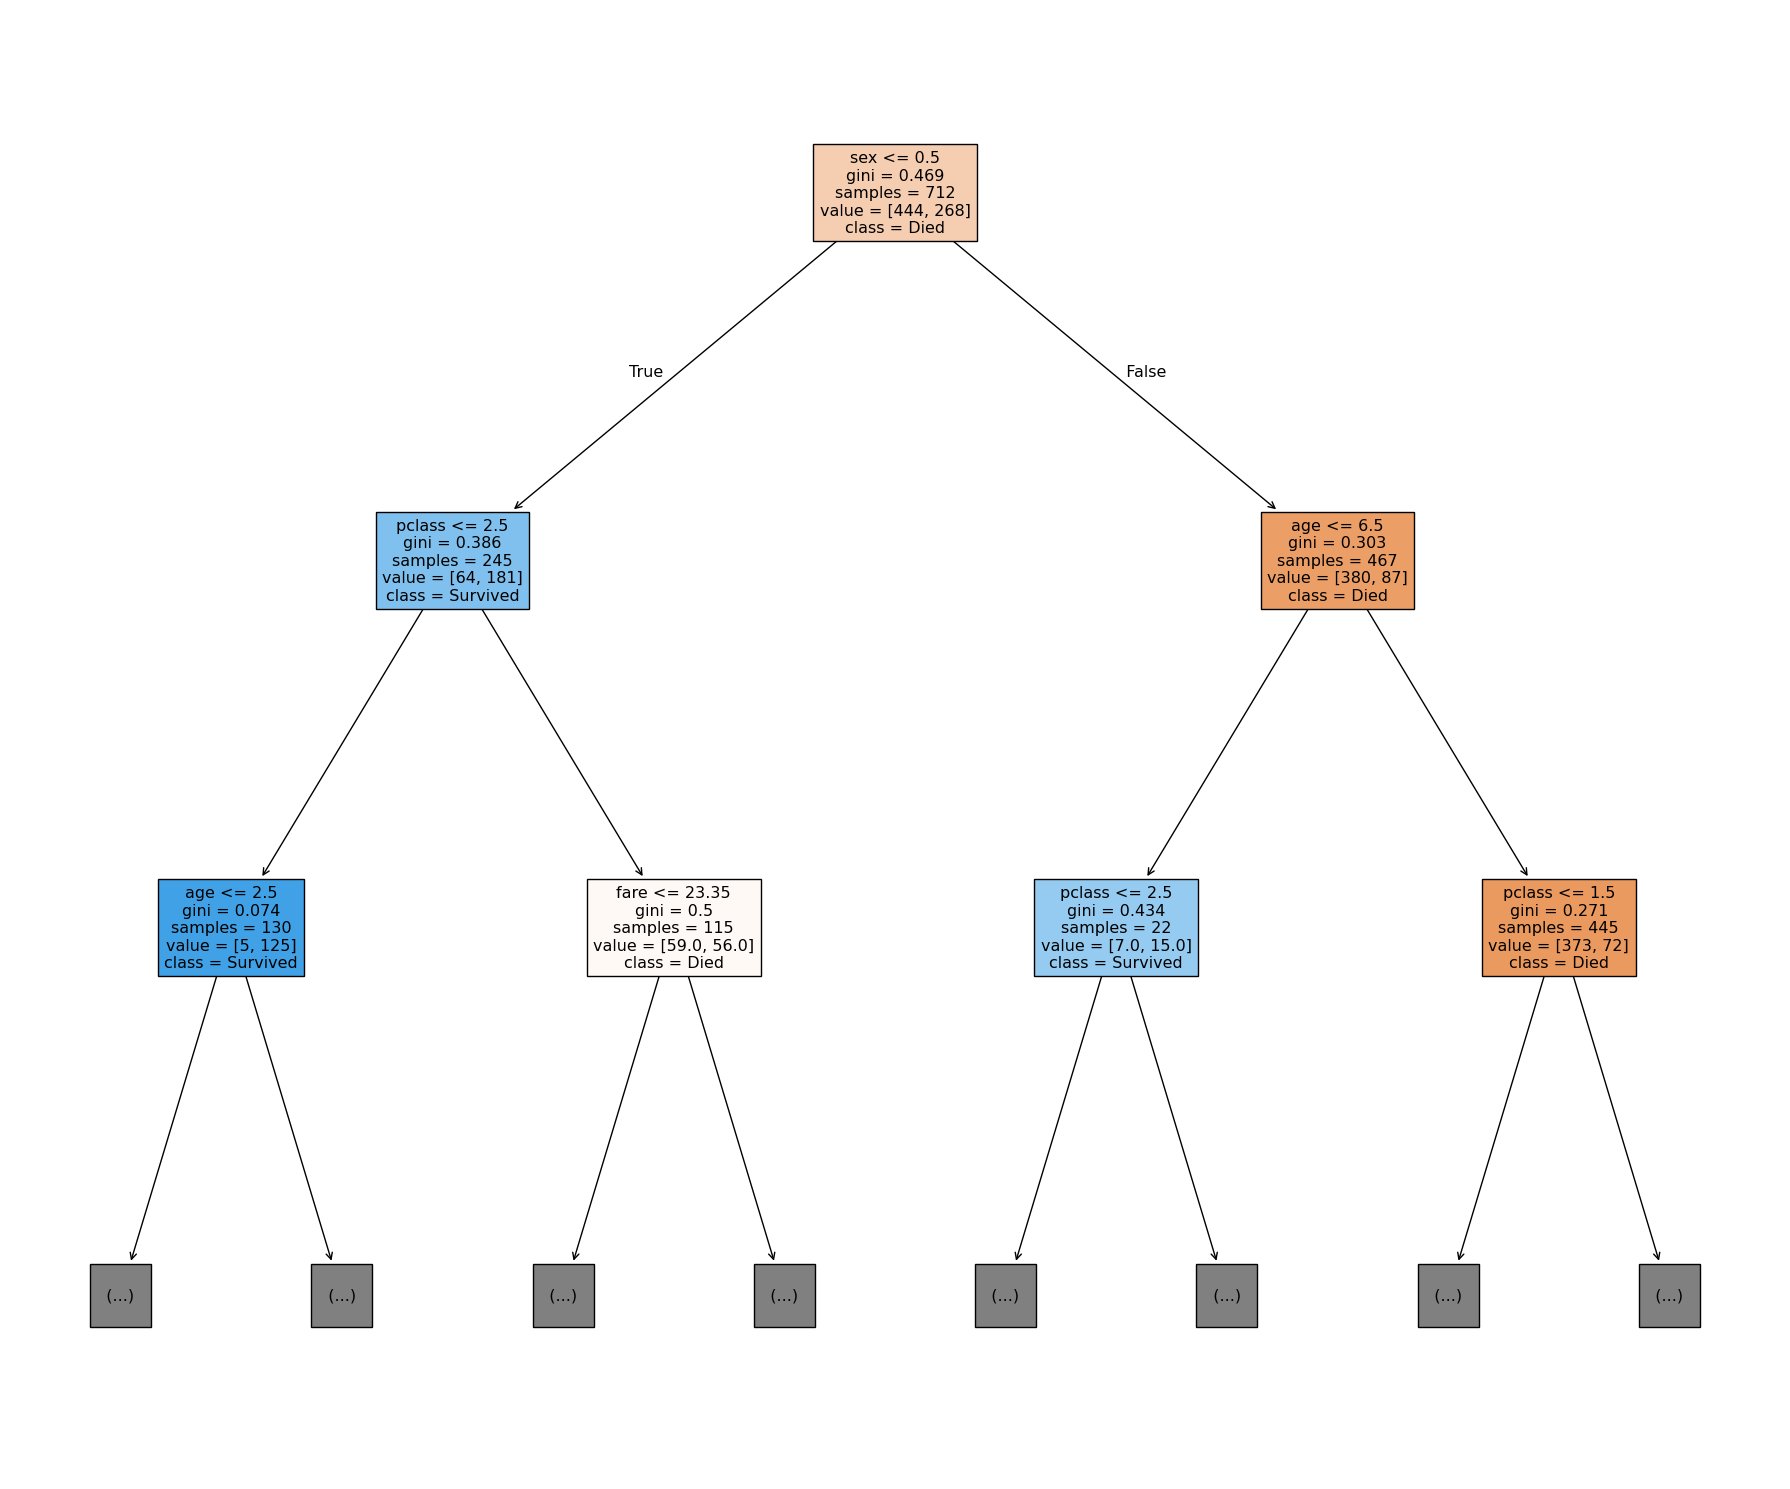

In [95]:
from sklearn.tree import plot_tree

plt.figure(figsize = (18,15))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True,
    max_depth = 2
)
plt.tight_layout()

# Decision Tree with  Pre-Pruning 

 for depth = 2, accuracy = 0.7653631284916201
 for depth = 3, accuracy = 0.7988826815642458
 for depth = 4, accuracy = 0.7988826815642458
 for depth = 5, accuracy = 0.7988826815642458
 for depth = 6, accuracy = 0.7988826815642458
 for depth = 7, accuracy = 0.7988826815642458
 for depth = 8, accuracy = 0.7932960893854749
 for depth = 9, accuracy = 0.7932960893854749
 for depth = 10, accuracy = 0.7932960893854749


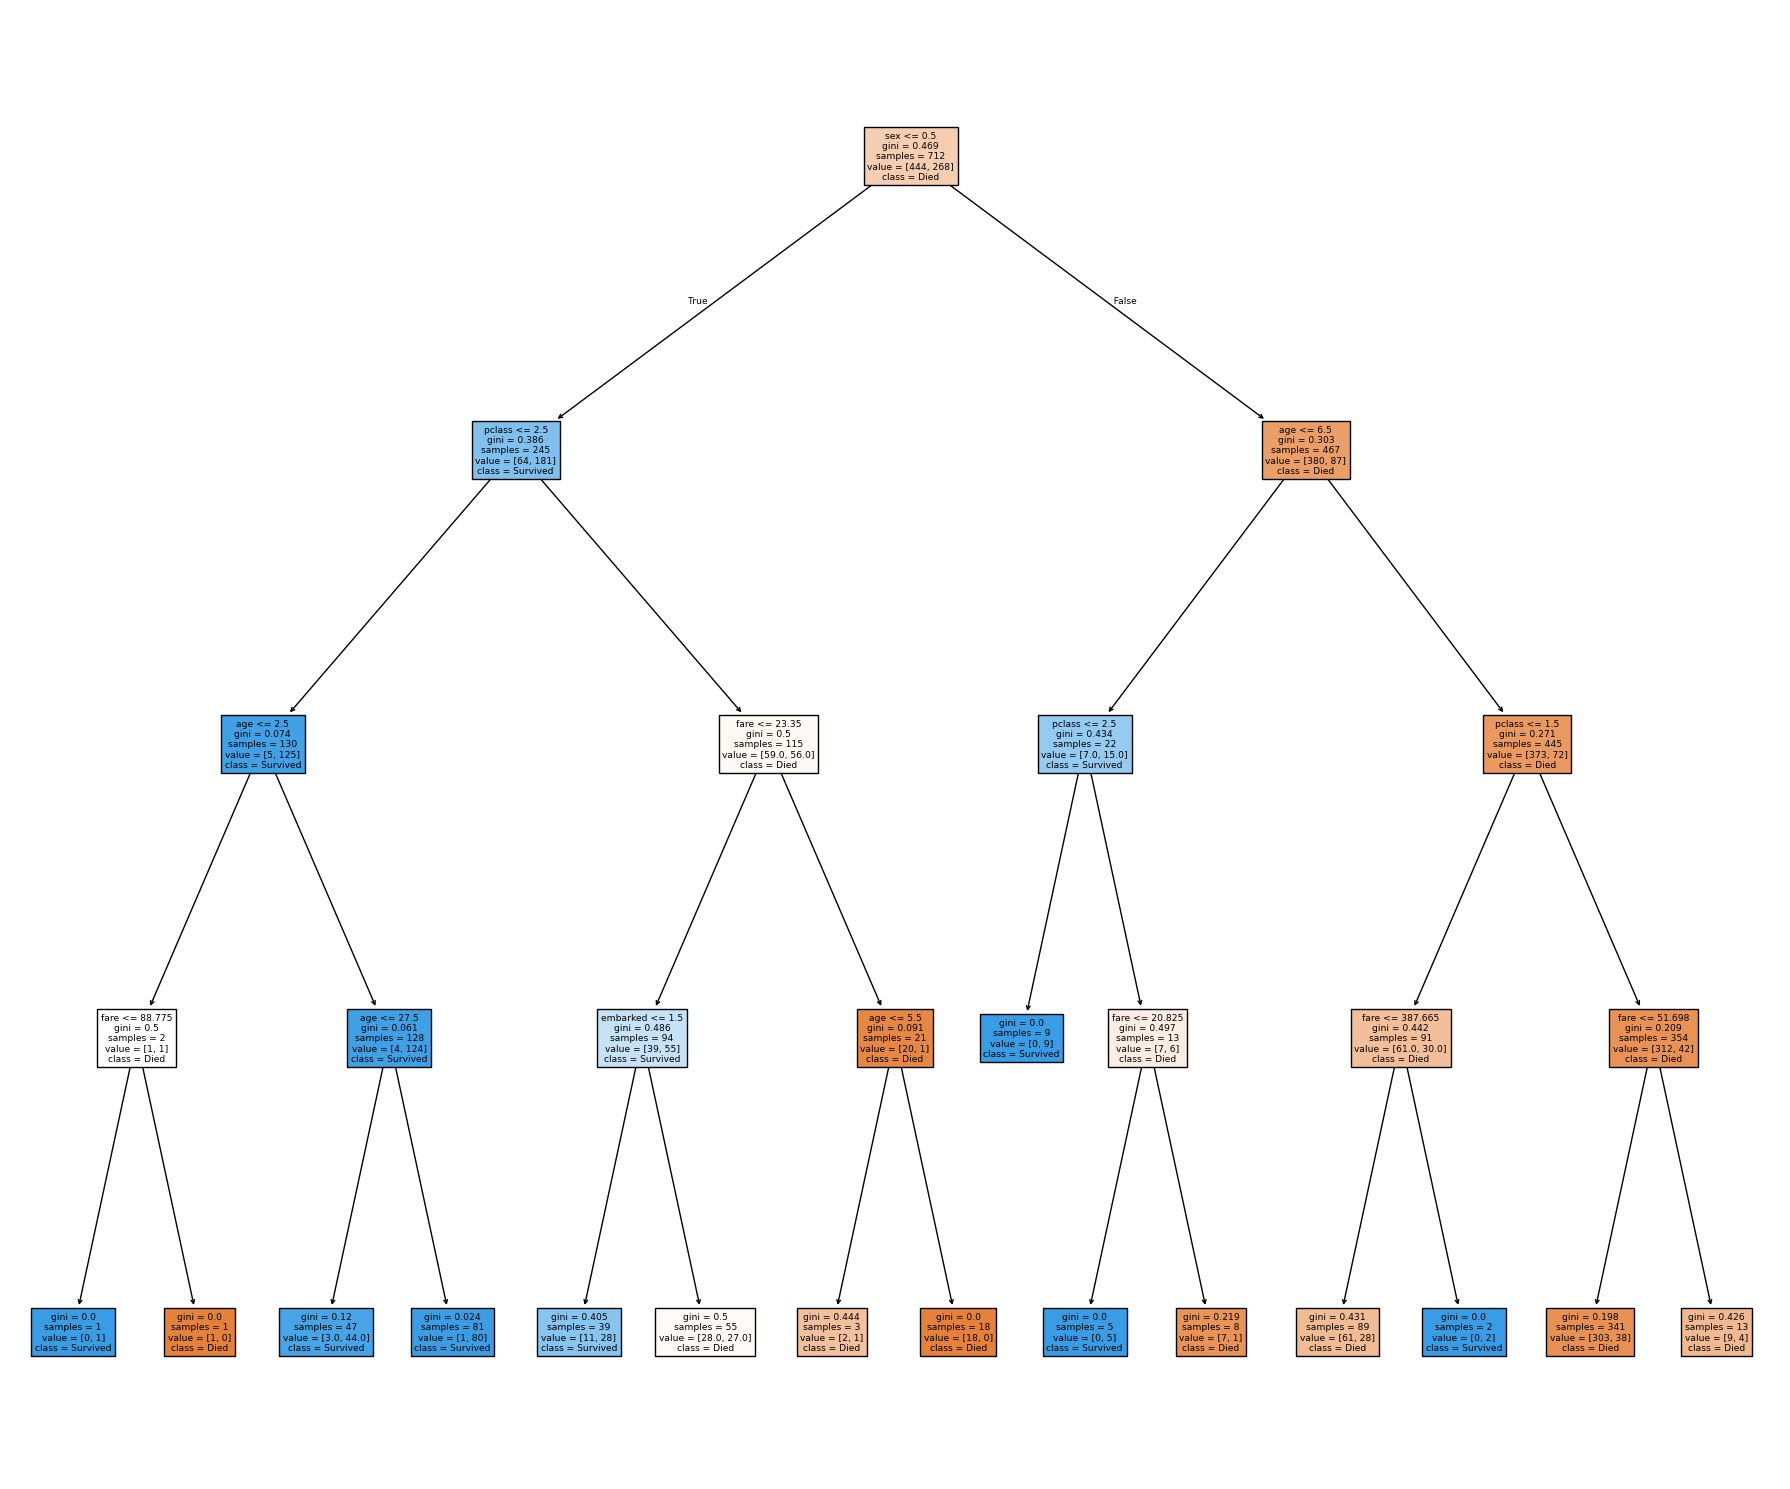

In [96]:
max_depths  = [2,3,4,5,6,7,8,9,10]

for depts in max_depths:
    model = DecisionTreeClassifier(max_depth=depts)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)   # score is accuracy matrix in decision tree
    print(f" for depth = {depts}, accuracy = {acc}")
    if depts == 4:
        plt.figure(figsize = (18,15))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died", "Survived"],
            filled = True
        )
        plt.tight_layout()

 for splits = 5, accuracy = 0.7988826815642458
 for splits = 10, accuracy = 0.7988826815642458
 for splits = 15, accuracy = 0.7988826815642458
 for splits = 20, accuracy = 0.7988826815642458
 for splits = 25, accuracy = 0.7932960893854749
 for splits = 30, accuracy = 0.7932960893854749


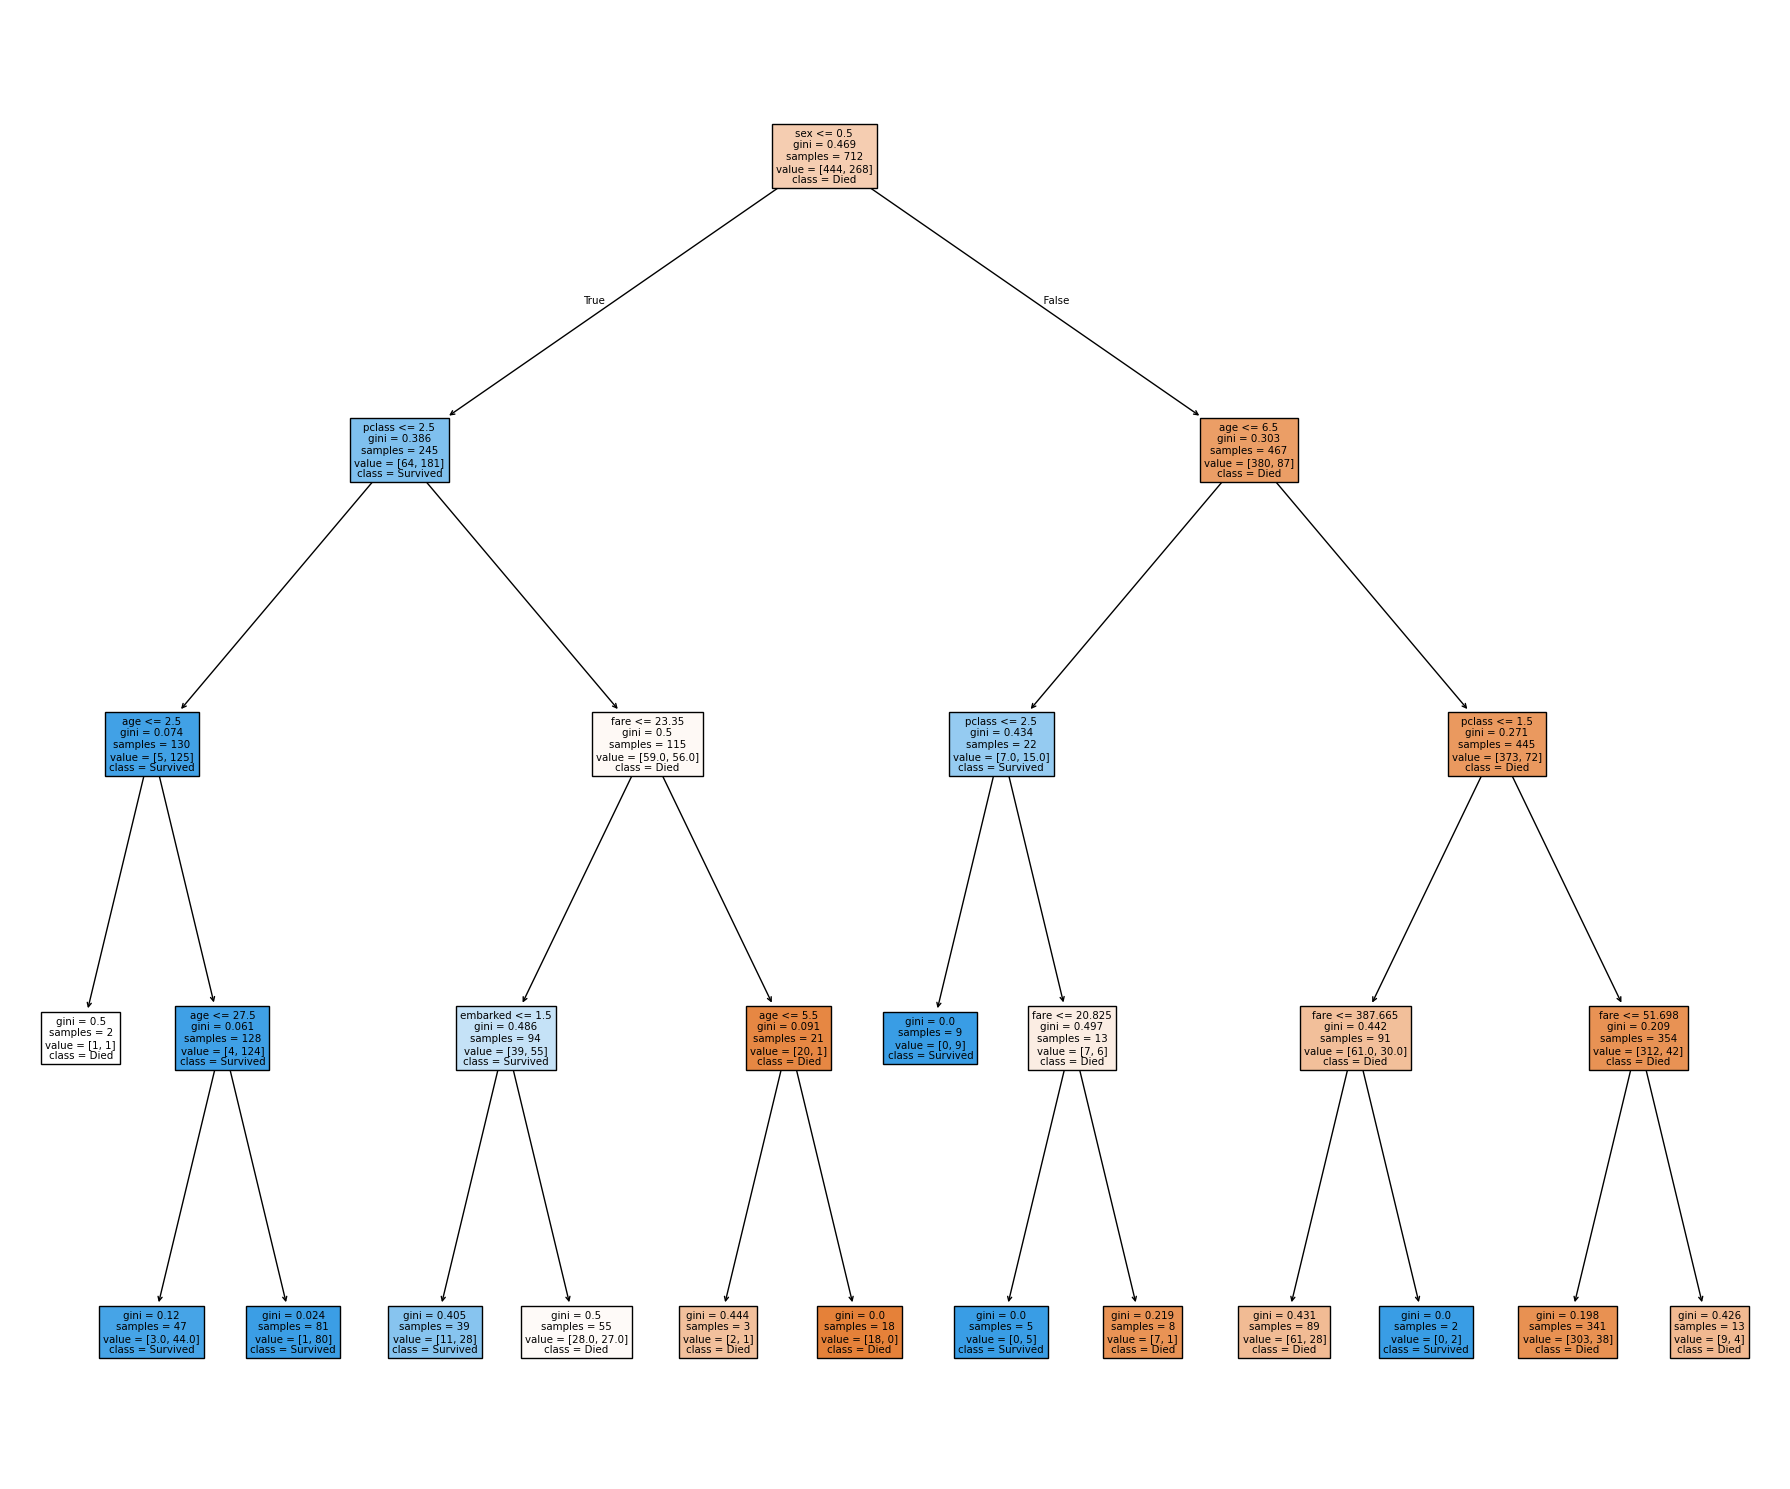

In [97]:
min_sample_splits  = [5,10,15,20,25,30]

for splits in min_sample_splits:
    model = DecisionTreeClassifier(max_depth = 4, min_samples_split = splits )
    
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)   # score is accuracy matrix in decision tree
    print(f" for splits = {splits}, accuracy = {acc}")
    if splits == 10:
        plt.figure(figsize = (18,15))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died", "Survived"],
            filled = True
        )
        plt.tight_layout()

# Decision Tree with Post-Pruning 

In [98]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [99]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

# Train Our Model For all alphas

In [100]:
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    trees.append((model,alpha))

In [101]:
best_acc = 0
best_alpha = 0
for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [102]:
best_alpha

np.float64(0.0015407231242023183)

In [103]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth = 4)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0015407231242023183), max_depth=4)

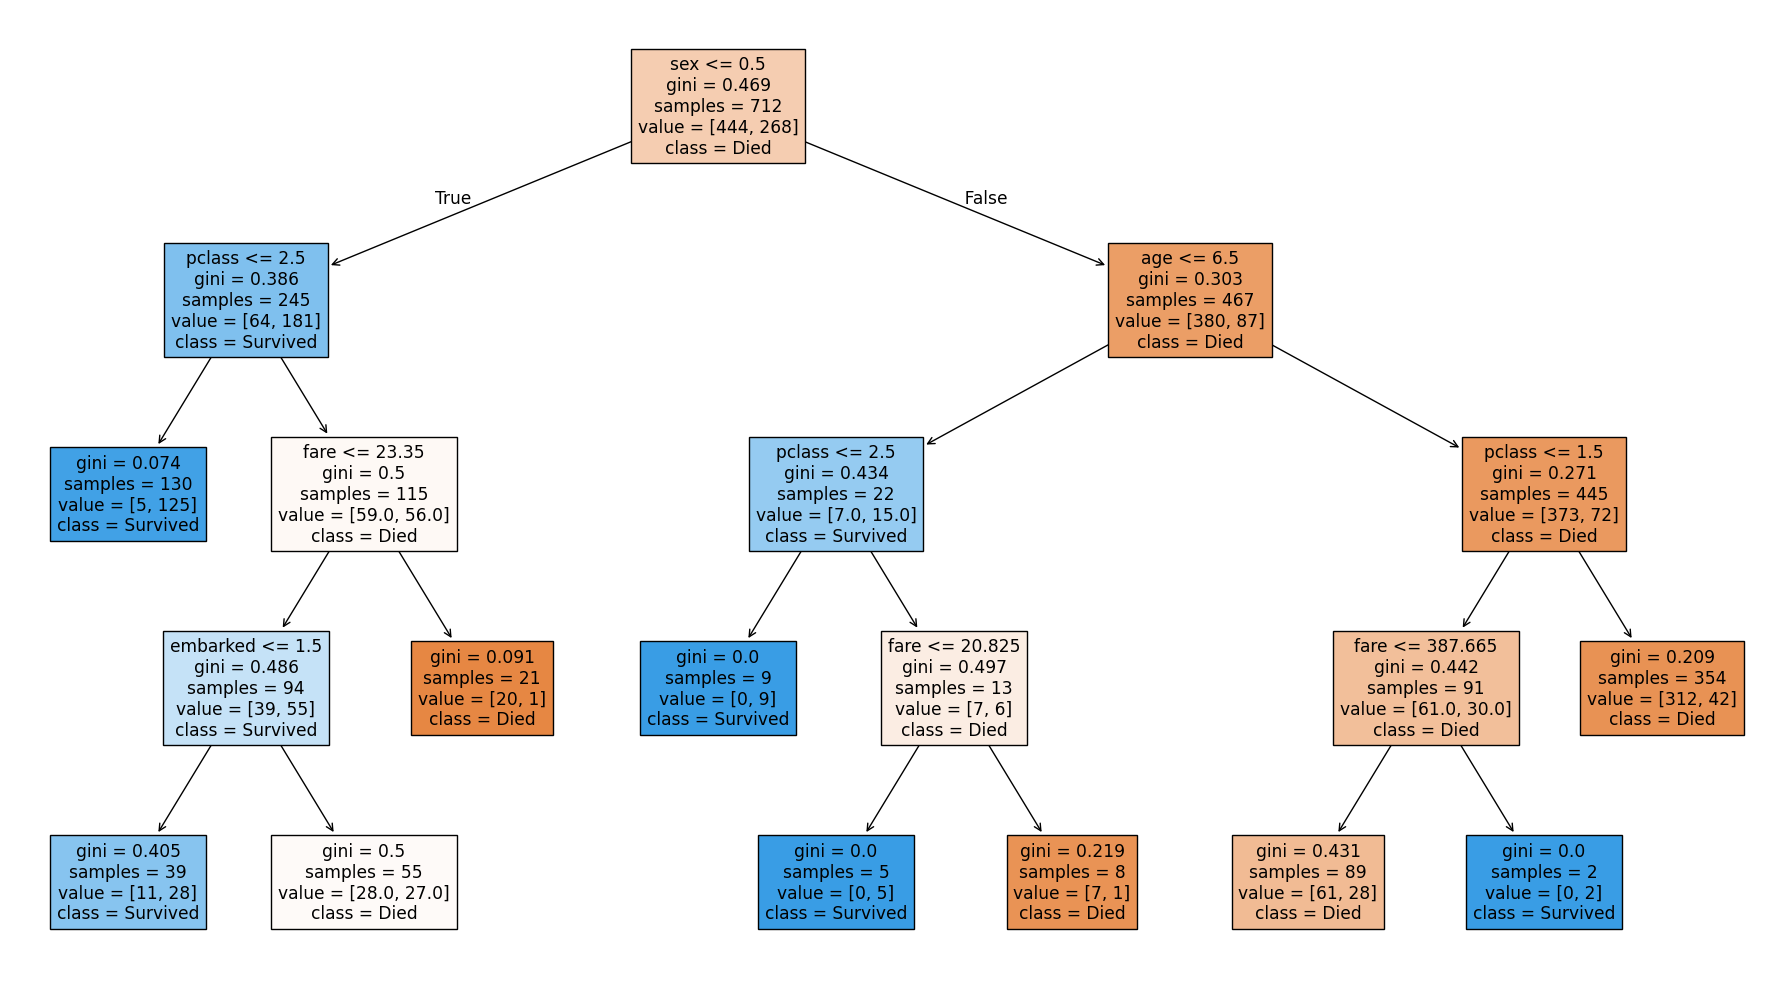

In [104]:
plt.figure(figsize = (18,10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True,
)
plt.tight_layout()

In [105]:
best_model.score(X_test, y_test)

0.7988826815642458